# EDA and Preprocessing — Pima Indians Diabetes (diabetes.csv)
**Author:** Hugo Manzano — 36231

## Dataset source
https://www.kaggle.com/code/mragpavank/pima-indians-diabetes-database/input

## Problem statement
Given medical measurements (e.g., *Glucose, BMI, Age*), the goal is to **predict whether a patient has diabetes**.
This is a **binary classification** problem:
- `Outcome = 1`: diabetes
- `Outcome = 0`: no diabetes

In the following sections, we perform EDA, analyze missing values (including missing values encoded as 0), and build a preprocessing **pipeline** plus an ML model while avoiding *data leakage*.


We start by importing the required libraries and loading the dataset into a pandas DataFrame.


In [3]:
import pandas as pd
import matplotlib .pyplot as plt
import seaborn as sns
from sklearn .impute import SimpleImputer
from sklearn .linear_model import LogisticRegression
from sklearn .model_selection import train_test_split
from sklearn .pipeline import make_pipeline
from sklearn .preprocessing import StandardScaler ,OneHotEncoder ,PowerTransformer
from sklearn .compose import ColumnTransformer

In [4]:
data =pd .read_csv ('diabetes.csv')
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [5]:
import numpy as np

cols_with_invalid_zeros =['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
data [cols_with_invalid_zeros ]=data [cols_with_invalid_zeros ].replace (0 ,np .nan )

data [cols_with_invalid_zeros ].isna ().sum ()

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


## Basic information and statistics

We can use the `.info()` method to get an overview of the dataset, including the number of non-null entries and data types for each column.

In [6]:
data .info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


## Columns, data types, and selected variables

For this problem:
- **Target variable (y):** `Outcome`
- **Predictor variables (X):** all other numeric columns in the dataset (8 variables).

Below is a table showing the data type of each column.


In [7]:
col_info = pd.DataFrame({
    "column": data.columns,
    "dtype": [str(t) for t in data.dtypes.values],
})
col_info


,column,dtype
0,Pregnancies,int64
1,Glucose,float64
2,BloodPressure,float64
3,SkinThickness,float64
4,Insulin,float64
5,BMI,float64
6,DiabetesPedigreeFunction,float64
7,Age,int64
8,Outcome,int64


Similarly, we can use the `.describe()` method to get summary statistics for the numerical columns in the dataset. Note that in this example, we are transposing the output for better readability.

In [8]:
data .describe ().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,763.0,121.686763,30.535641,44.000,99.00000,117.0000,141.00000,199.00
BloodPressure,733.0,72.405184,12.382158,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,541.0,29.153420,10.476982,7.000,22.00000,29.0000,36.00000,99.00
Insulin,394.0,155.548223,118.775855,14.000,76.25000,125.0000,190.00000,846.00
BMI,757.0,32.457464,6.924988,18.200,27.50000,32.3000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In total we have 9 columns:

Pregnancies: Number of times pregnant.

Glucose: Plasma glucose concentration a 2 hours in an oral glucose tolerance test.

BloodPressure: Diastolic blood pressure (mm Hg).

SkinThickness: Triceps skin fold thickness (mm).

Insulin: 2-Hour serum insulin (mu U/ml).

BMI: Body mass index (weight in kg/(height in m)^2).

DiabetesPedigreeFunction: A function which scores likelihood of diabetes based on family history.

Age: Age of the patient (years).

Outcome: Class variable (0 = No diabetes, 1 = Diabetes).

In our analysis, we will keep all the columns since they are all numerical and represent medical indicators that are directly related to the probability of having diabetes.

## Visualization of Numerical Features

Let's proceed with visualizing the distributions of the numerical features in the dataset. Note that even if the Outcome column is represented as an integer, it is categorical in nature (representing the presence or absence of diabetes) and will be skipped for this specific distribution analysis.

To visualize the distributions, we will use the seaborn library to create histograms with kernel density estimates (KDE) for each numerical column. This will help us identify the range of the data and detect anomalies, such as the high frequency of "0" values in variables like Insulin or BloodPressure.

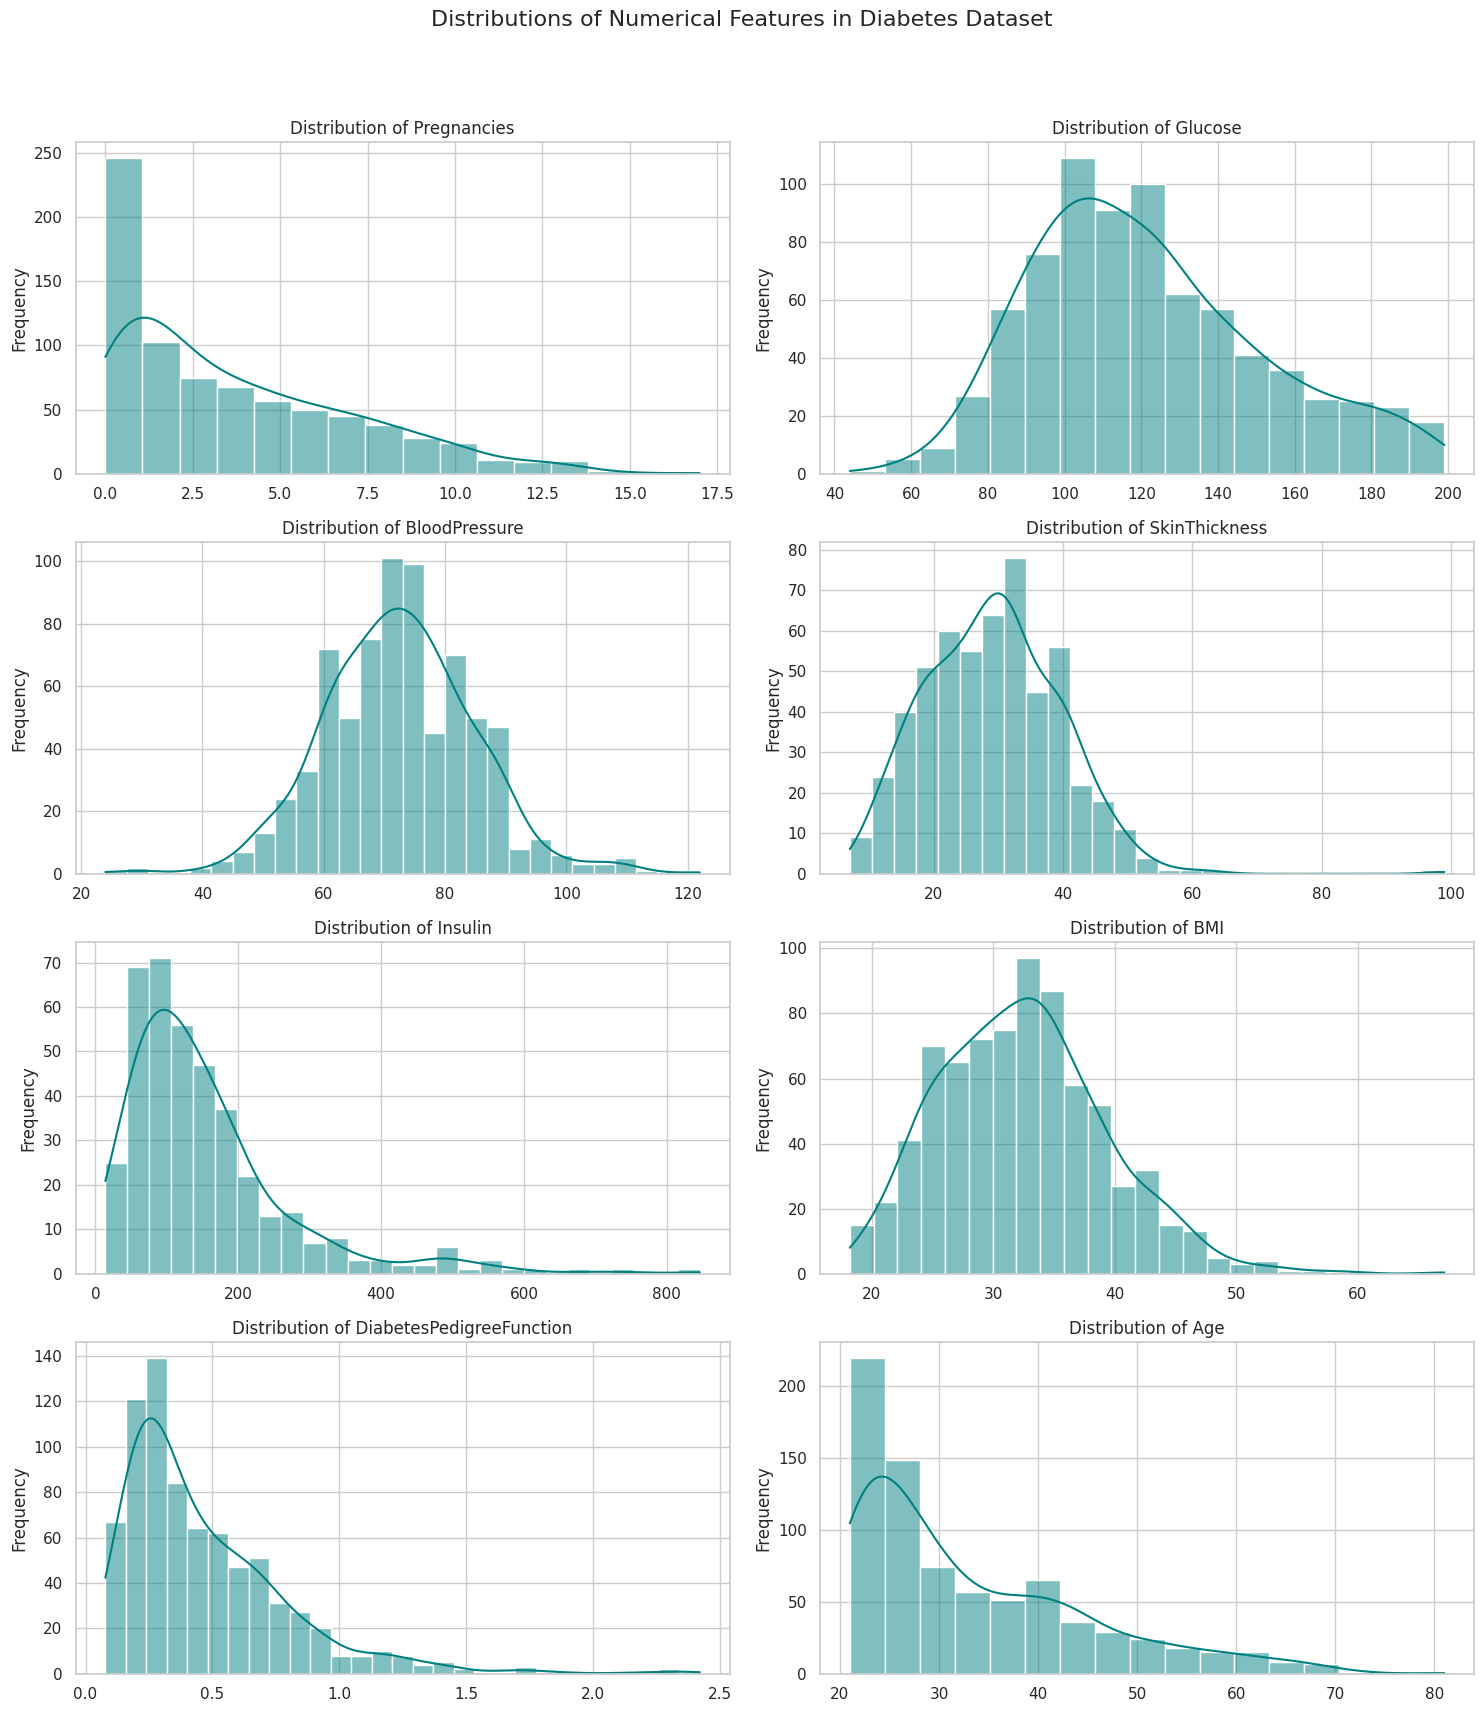

In [9]:
import seaborn as sns
import matplotlib .pyplot as plt

numerical_cols =['Pregnancies','Glucose','BloodPressure','SkinThickness',
'Insulin','BMI','DiabetesPedigreeFunction','Age']

sns .set_theme (style ="whitegrid")

fig ,axes =plt .subplots (nrows =4 ,ncols =2 ,figsize =(15 ,18 ))
fig .suptitle ('Distributions of Numerical Features in Diabetes Dataset',fontsize =16 )

for i ,col in enumerate (numerical_cols ):
    sns .histplot (data [col ],kde =True ,ax =axes [i //2 ,i %2 ],color ='teal')
    axes [i //2 ,i %2 ].set_title (f'Distribution of {col}',fontsize =12 )
    axes [i //2 ,i %2 ].set_xlabel ('')
    axes [i //2 ,i %2 ].set_ylabel ('Frequency')

plt .tight_layout (rect =[0 ,0.03 ,1 ,0.95 ])
plt .show ()

Upon inspecting the distributions, we identified a critical data quality issue: several features such as Glucose, BloodPressure, SkinThickness, Insulin, and BMI contain a significant number of entries with a value of 0. Given that these are biological measurements, a value of zero is medically impossible for a living patient and clearly indicates missing data. Treating these zeros as real values would introduce severe bias into the model. Therefore, before training, these zero values must be handled appropriately, either by imputation (replacing them with the median or mean) or by removal, to ensure the model learns from realistic physiological patterns.

## Target distribution (`Outcome`)

Even though the predictors are numeric, it is important to inspect the distribution of the target `Outcome` to identify potential **class imbalance**, which can influence model training and interpretation.


/tmp/ipython-input-4089717444.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns .countplot (x ='Outcome',data =data ,palette ='pastel',ax =axes [0 ])
/tmp/ipython-input-4089717444.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns .countplot (x ='Pregnancies',data =data ,palette ='viridis',ax =axes [1 ])


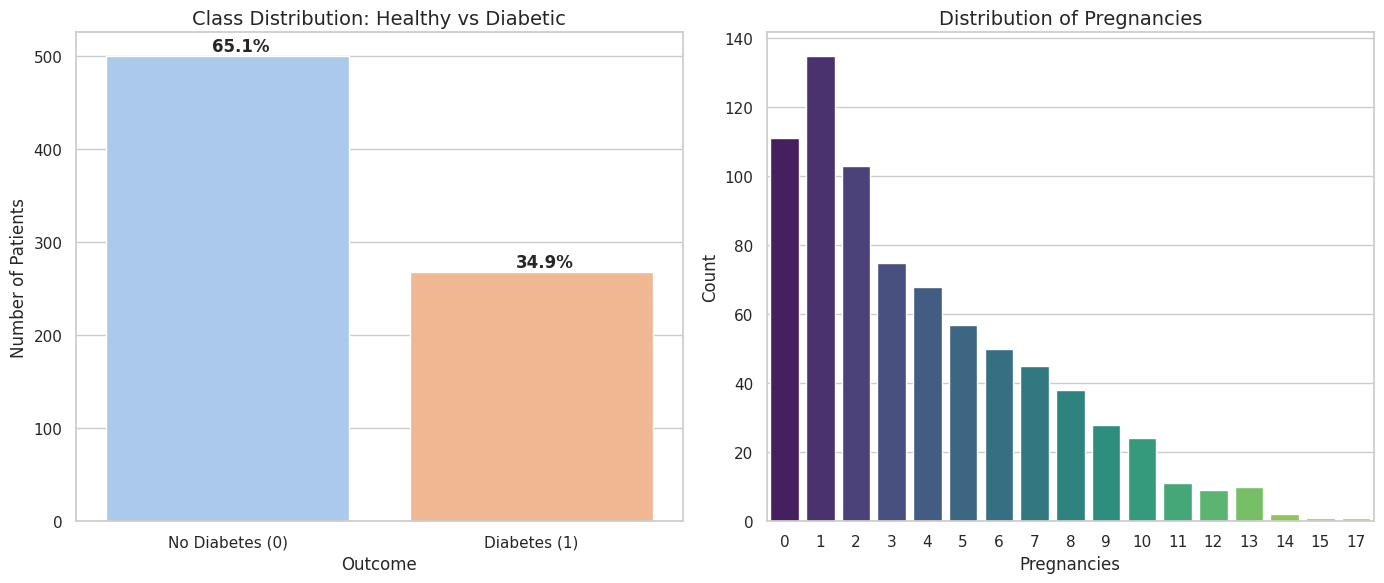

In [10]:

fig ,axes =plt .subplots (1 ,2 ,figsize =(14 ,6 ))

sns .countplot (x ='Outcome',data =data ,palette ='pastel',ax =axes [0 ])
axes [0 ].set_title ('Class Distribution: Healthy vs Diabetic',fontsize =14 )
axes [0 ].set_xticks ([0 ,1 ])
axes [0 ].set_xticklabels (['No Diabetes (0)','Diabetes (1)'])
axes [0 ].set_ylabel ('Number of Patients')

total =len (data )
for p in axes [0 ].patches :
    percentage ='{:.1f}%'.format (100 *p .get_height ()/total )
    x =p .get_x ()+p .get_width ()/2 -0.05
    y =p .get_height ()+5
    axes [0 ].annotate (percentage ,(x ,y ),size =12 ,weight ='bold')

sns .countplot (x ='Pregnancies',data =data ,palette ='viridis',ax =axes [1 ])
axes [1 ].set_title ('Distribution of Pregnancies',fontsize =14 )
axes [1 ].set_ylabel ('Count')

plt .tight_layout ()
plt .show ()

The output confirms that there are no longer any missing values in the dataset. By replacing the invalid zeros with the median, we have ensured that the model will learn from representative physiological data rather than being biased by missing information. The dataset is now complete and ready for the next stages of preprocessing.

## Target label distribution

After examining the class distribution, we investigate how the numerical features differ between the two classes (Healthy vs. Diabetic).

We will use Boxplots to visualize the statistical summary (median, quartiles, and outliers) of key features for each Outcome. This allows us to observe if there is a clear separation between the distributions of positive and negative cases.

We can also compare the survival counts between the rest of the features. For example, with numerical features, we can create boxplots to visualize the distribution of numerical features for survivors and non-survivors.

/tmp/ipython-input-1194580009.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns .boxplot (x ='Outcome',y =col ,data =data ,palette ='Set2',ax =axes [i //2 ,i %2 ])
/tmp/ipython-input-1194580009.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns .boxplot (x ='Outcome',y =col ,data =data ,palette ='Set2',ax =axes [i //2 ,i %2 ])
/tmp/ipython-input-1194580009.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns .boxplot (x ='Outcome',y =col ,data =data ,palette ='Set2',ax =axes [i //2 ,i %2 ])
/tmp/ipython-input-1194580009.py:8: FutureWarning: 

Passing `palette` wi

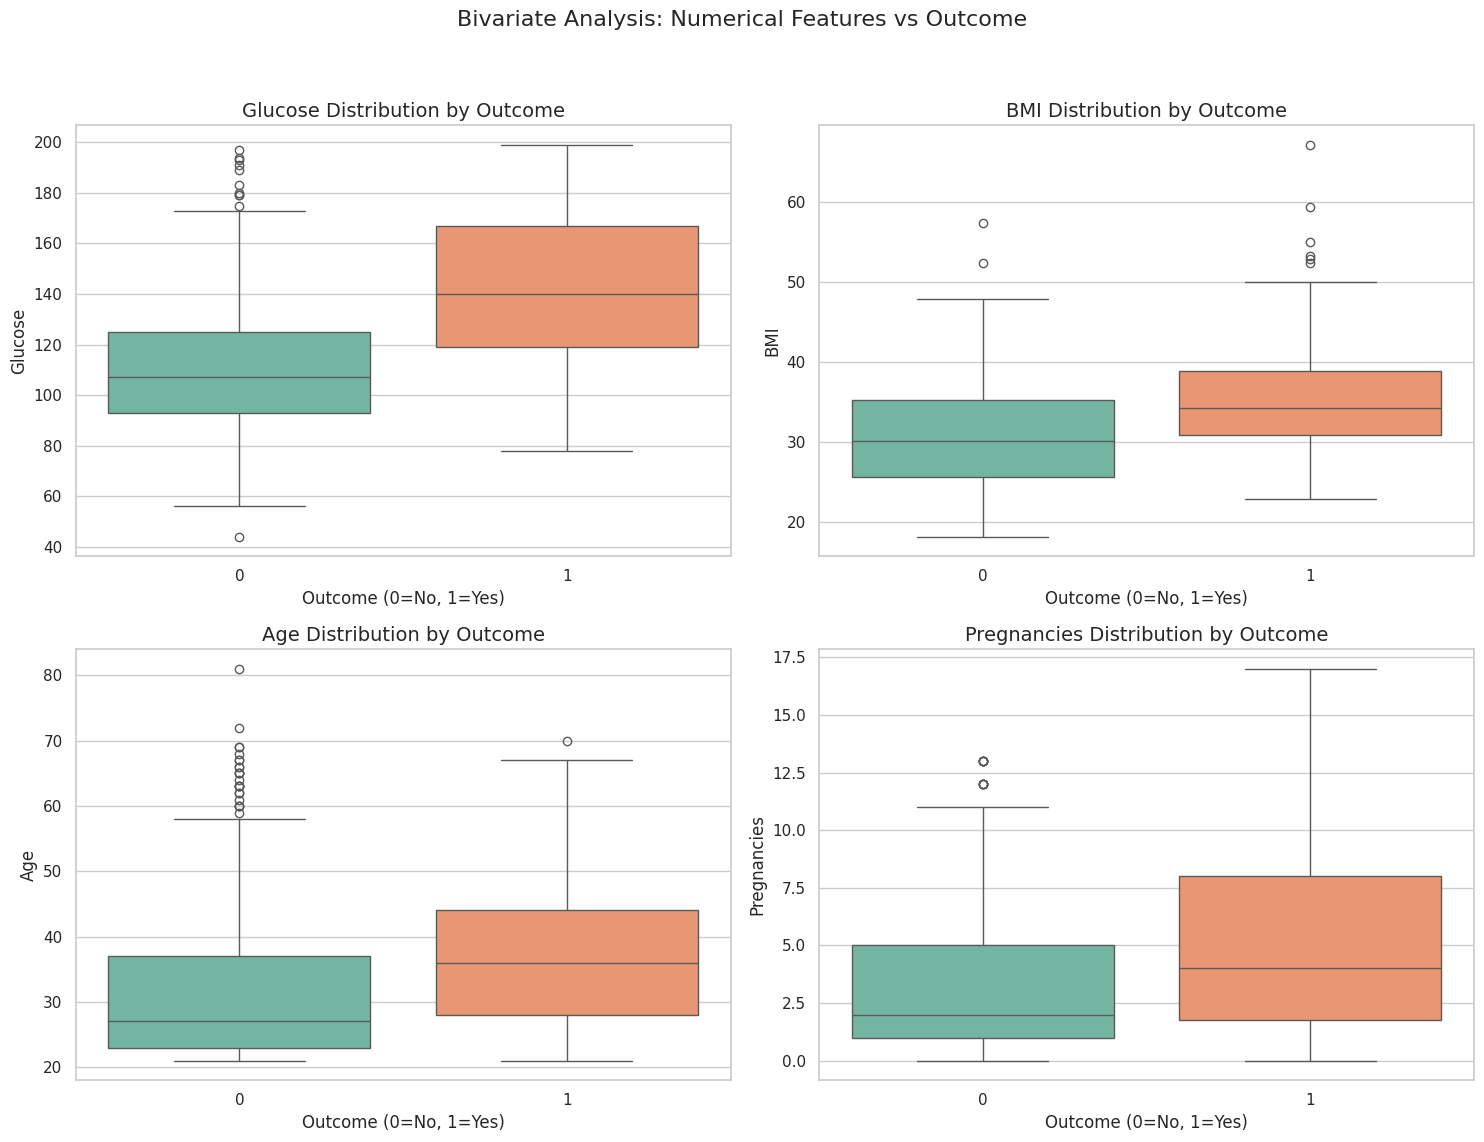

In [11]:

fig ,axes =plt .subplots (2 ,2 ,figsize =(15 ,12 ))
fig .suptitle ('Bivariate Analysis: Numerical Features vs Outcome',fontsize =16 )

features_to_plot =['Glucose','BMI','Age','Pregnancies']

for i ,col in enumerate (features_to_plot ):

    sns .boxplot (x ='Outcome',y =col ,data =data ,palette ='Set2',ax =axes [i //2 ,i %2 ])

    axes [i //2 ,i %2 ].set_title (f'{col} Distribution by Outcome',fontsize =14 )
    axes [i //2 ,i %2 ].set_xlabel ('Outcome (0=No, 1=Yes)')
    axes [i //2 ,i %2 ].set_ylabel (col )

plt .tight_layout (rect =[0 ,0.03 ,1 ,0.95 ])
plt .show ()

The boxplots reveal significant distinct patterns between healthy and diabetic patients. Most notably, Glucose exhibits the clearest separation, where the median level for diabetic patients is substantially higher than for non-diabetic ones, confirming its status as a strong predictor. Similarly, Age and BMI show higher medians for the diabetic class, indicating that older individuals and those with a higher body mass index are at greater risk. While outliers are present in features like BMI (indicated by the points beyond the whiskers), the shift in distribution for these key variables suggests they hold high predictive value for our model.

We can also use a correlation matrix heatmap to visualize linear relationships between all numerical variables (including the target `Outcome`).  

This helps quantify patterns hinted at by the previous plots (for example, whether `Glucose` or `BMI` tend to move together with `Outcome`).  
Because this dataset is purely numerical, we do **not** have categorical columns that require one-hot encoding here.

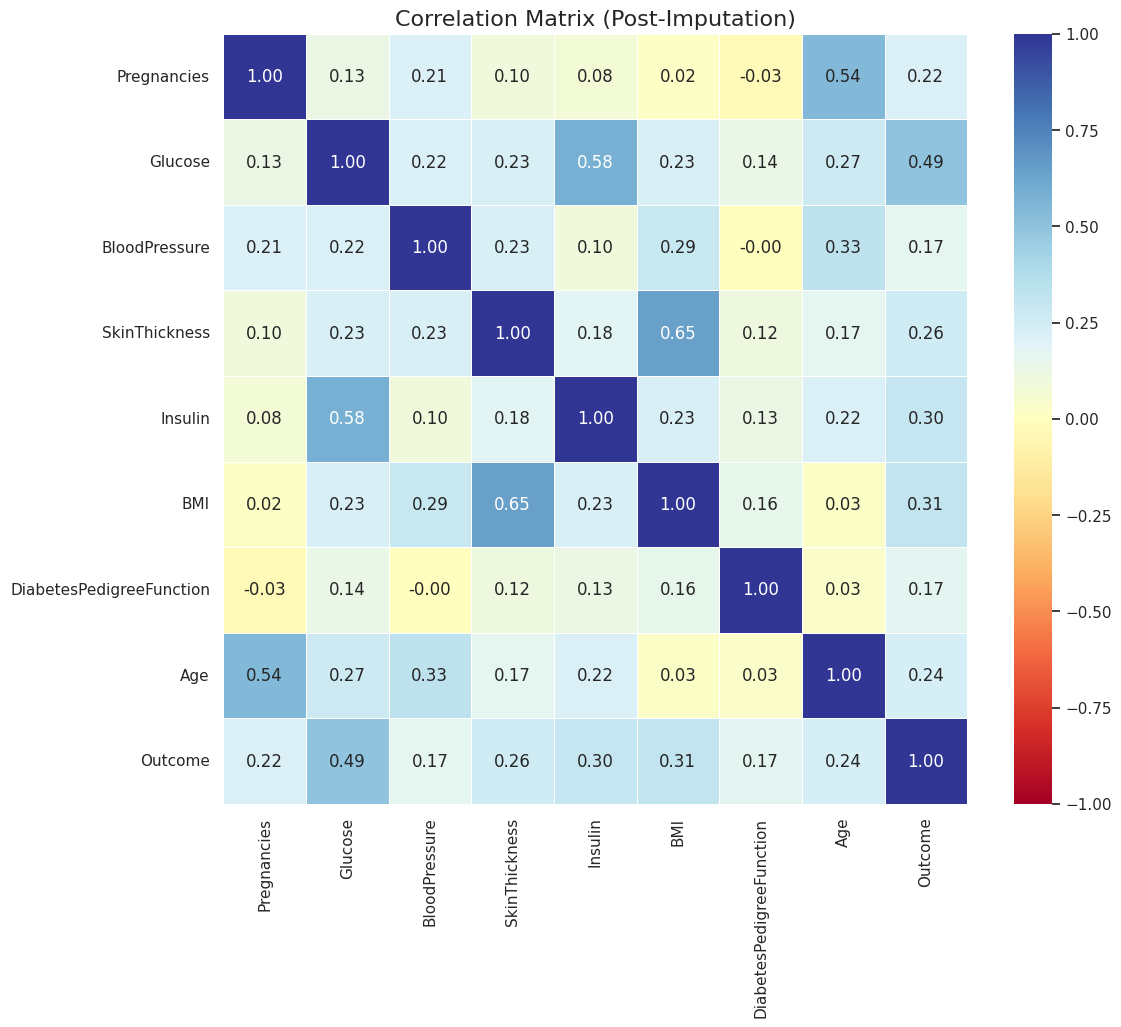

In [12]:
import seaborn as sns
import matplotlib .pyplot as plt

corr_matrix =data .corr ()

plt .figure (figsize =(12 ,10 ))

sns .heatmap (corr_matrix ,
annot =True ,
fmt =".2f",
cmap ='RdYlBu',
vmin =-1 ,vmax =1 ,
linewidths =0.5 )

plt .title ('Correlation Matrix (Post-Imputation)',fontsize =16 )
plt .show ()

### Key EDA findings (summary)

- **Outcome balance:** the class distribution is not perfectly balanced, so it's important to handle class balance appropriately.
- **Strong signals:** `Glucose` typically shows the clearest separation between Outcome classes, followed by `BMI` and `Age`.
- **Outliers / skew:** variables like `Insulin` and `SkinThickness` tend to be skewed and can contain extreme values; median imputation is more robust here.
- **Missingness:** several medical measurements may be missing (encoded as invalid zeros). Treating those as NaN avoids biased preprocessing.


## Handling Missing Values

Before building preprocessing pipelines, it is important to analyze missing values in the dataset.  

**Important:** in this dataset, some missing measurements are encoded as **0** (e.g., `Glucose`, `BMI`, `Insulin`). We converted those invalid zeros to **NaN** above, so the missing-value analysis below reflects the *true* missingness.

<Axes: >

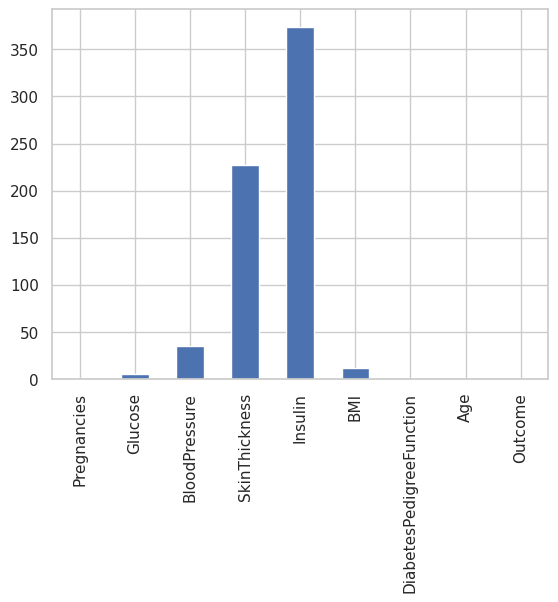

In [13]:
missing_counts =data .isnull ().sum ()
missing_counts .plot (kind ='bar')

We can also calculate the percentage of missing values for each column to get a better understanding of the extent of missing data.

In [14]:
missing_percent =data .isna ().mean ()*100
missing_percent .sort_values (ascending =False )

,0
Insulin,48.697917
SkinThickness,29.557292
BloodPressure,4.557292
BMI,1.432292
Glucose,0.651042
Pregnancies,0.000000
DiabetesPedigreeFunction,0.000000
Age,0.000000
Outcome,0.000000


With the missing-value analysis above (including the *invalid zeros* converted to NaN), we can define a robust strategy for preprocessing:

- **Numerical features**: impute missing values using the **median** (more robust to outliers than the mean).
- **Scaling**: apply **StandardScaler** so features with very different ranges (e.g., `Insulin` vs `DiabetesPedigreeFunction`) are comparable for models like Logistic Regression.

Because all features are numerical, we do not need categorical encoders in this notebook.

## Preprocessing pipelines

Now that we have analyzed the dataset and manually handled the invalid zero values, we can proceed to build preprocessing pipelines to standardize the data for the model.

We can declaratively create a preprocessing pipeline using ColumnTransformer. Since our dataset is purely numerical, we do not need categorical encodings like One-Hot Encoding. However, scaling is critical. The transformations we will apply are:

To all numerical columns (Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age):

Impute missing values: We will add a SimpleImputer with the median strategy. Even though we already cleaned the data manually, including this step in the pipeline ensures that any future data (like the Test set) is automatically handled correctly.

Standard Scaling: We will apply StandardScaler to normalize the features (mean=0, variance=1), ensuring that variables with larger ranges (like Insulin) do not dominate the model over smaller ones (like DiabetesPedigreeFunction).

In [15]:
from sklearn .model_selection import train_test_split

X =data .drop ('Outcome',axis =1 )
y =data ['Outcome']

X_train ,X_test ,y_train ,y_test =train_test_split (X ,y ,test_size =0.2 ,random_state =42 )

print (f"Data successfully split. X shape: {X.shape}")

Data successfully split. X shape: (768, 8)


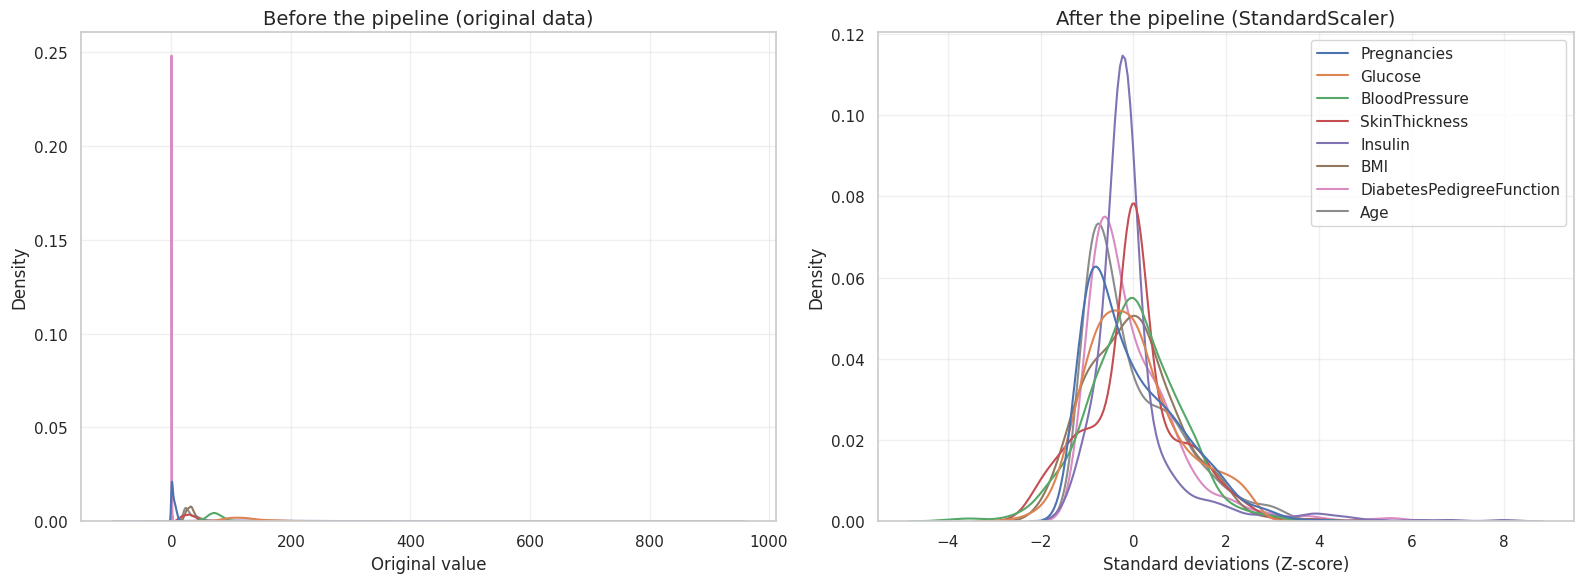

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

numerical_cols = X.columns.tolist()

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_cols),
    ]
)

X_train_scaled = preprocessor.fit_transform(X_train)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=numerical_cols)

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(16, 6))

sns.kdeplot(data=X_train, ax=ax1, legend=False)
ax1.set_title("Before the pipeline (original data)", fontsize=14)
ax1.set_xlabel("Original value")
ax1.set_ylabel("Density")
ax1.grid(True, alpha=0.3)

sns.kdeplot(data=X_train_scaled_df, ax=ax2, legend=True)
ax2.set_title("After the pipeline (StandardScaler)", fontsize=14)
ax2.set_xlabel("Standard deviations (Z-score)")
ax2.set_ylabel("Density")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


The visualization above confirms the effectiveness of the preprocessing pipeline.

Left Plot (Original): Features have vastly different scales (e.g., Insulin vs. Pedigree Function), which would confuse the Logistic Regression model.

Right Plot (Scaled): After passing through the StandardScaler, all features are normalized (centered at 0 with unit variance). This ensures that every variable contributes equally to the model's decision-making process.

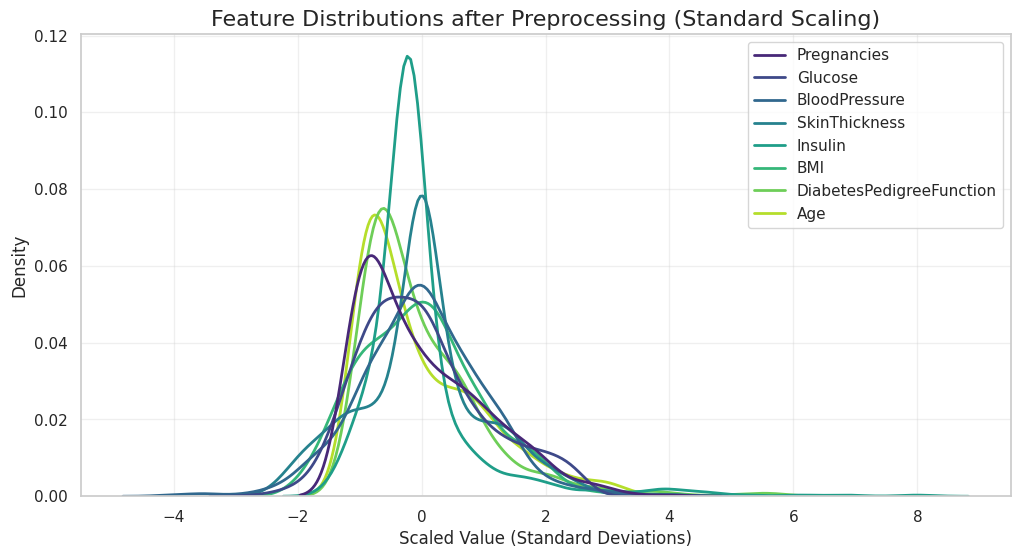

In [17]:


X_train_processed =preprocessor .fit_transform (X_train )

X_train_processed_df =pd .DataFrame (X_train_processed ,columns =numerical_cols )

plt .figure (figsize =(12 ,6 ))
sns .kdeplot (data =X_train_processed_df ,linewidth =2 ,palette ='viridis')

plt .title ('Feature Distributions after Preprocessing (Standard Scaling)',fontsize =16 )
plt .xlabel ('Scaled Value (Standard Deviations)')
plt .ylabel ('Density')
plt .grid (True ,alpha =0.3 )
plt .show ()

Analysis of Scaled Distributions

The plot above demonstrates the effect of the StandardScaler. All numerical features have been transformed to have a mean of approximately 0 and a standard deviation of 1.

Unlike the original raw data, where Insulin (ranging up to 800) and DiabetesPedigreeFunction (ranging 0-2) were incomparable, now all features share the same scale. This is crucial for the Logistic Regression algorithm to function correctly, as it treats all features with equal importance during the optimization process.

## Building a Classification Model

Now that the data preprocessing pipeline is established, we can define the final model. For this binary classification problem, we will use Logistic Regression.

We will create a full pipeline that combines the preprocessing steps (Imputation + Scaling) with the Classifier. This ensures that the data is automatically processed before being fed into the model during training and future predictions.

In [18]:
from sklearn .linear_model import LogisticRegression
model =LogisticRegression (random_state =42 ,solver ='liblinear')
clf =Pipeline (steps =[
('preprocessor',preprocessor ),
('classifier',model )
])
clf .fit (X_train ,y_train )
print ("Model trained successfully!")


Model trained successfully!


The `classification_model` object is now a complete pipeline that first preprocesses the input data and then applies logistic regression for classification. If we output the steps of the pipeline, we can see the individual components that make up the complete model.

In [19]:
clf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pregnancies', 'Glucose',
                                                   'BloodPressure',
                                                   'SkinThickness', 'Insulin',
                                                   'BMI',
                                                   'DiabetesPedigreeFunction',
                                                   'Age'])])),
                ('classifier',
                 LogisticRegression(random_state=42, solver='liblinear'))])

Now that the pipeline is set up, we can fit the model to the training data using the `fit` method. This will internally call the `fit_transform` method of the preprocessing pipeline on the training data, followed by fitting the logistic regression model on the transformed data.

In [20]:
clf .fit (X_train ,y_train )

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pregnancies', 'Glucose',
                                                   'BloodPressure',
                                                   'SkinThickness', 'Insulin',
                                                   'BMI',
                                                   'DiabetesPedigreeFunction',
                                                   'Age'])])),
                ('classifier',
                 LogisticRegression(random_state=42, solver='liblinear'))])

With our trained model, we can now make predictions on the test set using the `predict` method. This will internally call the `transform` method of the preprocessing pipeline on the test data, followed by making predictions using the logistic regression model.

In [21]:
y_test_pred =clf .predict (X_test )
y_test_pred [:20 ]

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1])